# Data Augmentation

In [5]:
import os
import numpy as np
import cv2
import random
from google.colab.patches import cv2_imshow
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Configuration

In [11]:
POSTERS_BASE_FOLDER = '/content/drive/MyDrive/construction_site/input/posters'
LOGOS_FOLDER        = '/content/drive/MyDrive/construction_site/input/logos'
OUTPUT_BASE_FOLDER  = '/content/drive/MyDrive/construction_site/output'

# Input Poster Folders
POSTERS_TRAIN_FOLDER = os.path.join(POSTERS_BASE_FOLDER, 'train')
POSTERS_TEST_FOLDER  = os.path.join(POSTERS_BASE_FOLDER, 'test')
POSTERS_VAL_FOLDER   = os.path.join(POSTERS_BASE_FOLDER, 'val')

# Output Image Folders
OUTPUT_IMAGE_TRAIN_FOLDER = os.path.join(OUTPUT_BASE_FOLDER, 'images', 'train')
OUTPUT_IMAGE_TEST_FOLDER  = os.path.join(OUTPUT_BASE_FOLDER, 'images', 'test')
OUTPUT_IMAGE_VAL_FOLDER   = os.path.join(OUTPUT_BASE_FOLDER, 'images', 'val')

# Output Label Folders
OUTPUT_LABEL_TRAIN_FOLDER = os.path.join(OUTPUT_BASE_FOLDER, 'labels', 'train')
OUTPUT_LABEL_TEST_FOLDER  = os.path.join(OUTPUT_BASE_FOLDER, 'labels', 'test')
OUTPUT_LABEL_VAL_FOLDER   = os.path.join(OUTPUT_BASE_FOLDER, 'labels', 'val')

# Create all necessary directories
for folder in [LOGOS_FOLDER,
               POSTERS_TRAIN_FOLDER, POSTERS_TEST_FOLDER, POSTERS_VAL_FOLDER,
               OUTPUT_IMAGE_TRAIN_FOLDER, OUTPUT_IMAGE_TEST_FOLDER, OUTPUT_IMAGE_VAL_FOLDER,
               OUTPUT_LABEL_TRAIN_FOLDER, OUTPUT_LABEL_TEST_FOLDER, OUTPUT_LABEL_VAL_FOLDER]:
    os.makedirs(folder, exist_ok=True)


CLASS_MAP = {
    "NYC_Correct":  0, "NYC_Incorrect":  1,
    "BP_Correct":   2, "BP_Incorrect":   3,
    "SK_Correct":   4, "SK_Incorrect":   5,
    "YORP_Correct": 6, "YORP_Incorrect": 7,
}

LOGO_CONFIG = {
    "NYC":  {"keyword": "nyc",  "correct_prob": 0.5},
    "BP":   {"keyword": "bp",   "correct_prob": 0.4},
    "SK":   {"keyword": "sk",   "correct_prob": 0.6},
    "YORP": {"keyword": "yorp", "correct_prob": 0.6},
}

## Load Assets

In [12]:
def load_poster_files(folder):
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

poster_files_train = load_poster_files(POSTERS_TRAIN_FOLDER)
poster_files_test  = load_poster_files(POSTERS_TEST_FOLDER)
poster_files_val   = load_poster_files(POSTERS_VAL_FOLDER)

all_logo_files = [os.path.join(LOGOS_FOLDER, f) for f in os.listdir(LOGOS_FOLDER)
                  if f.lower().endswith('.png')]

loaded_logos = {}
for brand, cfg in LOGO_CONFIG.items():
    kw = cfg['keyword']
    matches = [f for f in all_logo_files if kw in os.path.basename(f).lower()]
    if not matches:
        print(f"Warning: No {brand} logos found (keyword '{kw}') in {LOGOS_FOLDER}")
    loaded_logos[brand] = {os.path.basename(f): cv2.imread(f, cv2.IMREAD_UNCHANGED)
                           for f in matches}

print(f"Train Posters: {len(poster_files_train)}")
print(f"Test Posters: {len(poster_files_test)}")
print(f"Validation Posters: {len(poster_files_val)}")
for brand, logos in loaded_logos.items():
    print(f"  {brand}: {len(logos)} logo(s)")

Train Posters: 448
Test Posters: 96
Validation Posters: 100
  NYC: 2 logo(s)
  BP: 2 logo(s)
  SK: 4 logo(s)
  YORP: 3 logo(s)


## Logo Transformations

In [13]:
def distort_logo(logo):
    h, w = logo.shape[:2]
    if random.randint(0, 1) == 0:
        new_w = int(w * random.uniform(1.1, 1.2))
        new_h = int(h * random.uniform(0.85, 0.9))
    else:
        new_w = int(w * random.uniform(0.85, 0.9))
        new_h = int(h * random.uniform(1.1, 1.2))
    return cv2.resize(logo, (new_w, new_h))


def incomplete_logo(logo):
    h, w = logo.shape[:2]
    n = random.randint(2, 4)
    crop_side = random.choice(['top', 'bottom', 'left', 'right'])
    if crop_side == 'top':
        return logo[min(h // n, h - 1):, :]
    elif crop_side == 'bottom':
        return logo[:h - min(h // n, h - 1), :]
    elif crop_side == 'left':
        return logo[:, min(w // n, w - 1):]
    else:
        return logo[:, :w - min(w // n, w - 1)]


def rotate_logo(logo):
    h, w = logo.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), random.randint(-90, 90), 1)
    if logo.shape[2] == 4:
        rotated_bgr   = cv2.warpAffine(logo[:, :, :3], M, (w, h),
                                        borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
        rotated_alpha = cv2.warpAffine(logo[:, :, 3],  M, (w, h),
                                        borderMode=cv2.BORDER_CONSTANT, borderValue=0)
        return np.dstack((rotated_bgr, rotated_alpha))
    return cv2.warpAffine(logo, M, (w, h))


def wrong_color_logo(logo):
    alpha_strength = random.uniform(0.3, 0.6)
    color = np.array([random.randint(0, 255) for _ in range(3)], dtype=np.uint8)
    bgr   = logo[:, :, :3]
    logo_f    = bgr.astype(float) / 255.0
    overlay_f = np.full_like(logo_f, color / 255.0)
    tinted = logo_f * overlay_f
    output = (alpha_strength * tinted + (1 - alpha_strength) * logo_f) * 255
    if logo.shape[2] == 4:
        return np.dstack((output.astype(np.uint8), logo[:, :, 3]))
    return output.astype(np.uint8)


def apply_random_transformations(logo, max_dim=120):
    transforms = [distort_logo, incomplete_logo, wrong_color_logo, rotate_logo]
    selected   = random.sample(transforms, random.randint(1, 3))
    result     = logo.copy()
    names      = []
    for fn in selected:
        result = fn(result)
        names.append(fn.__name__)
    h, w = result.shape[:2]
    if h > max_dim or w > max_dim:
        scale  = max_dim / max(h, w)
        result = cv2.resize(result, (int(w * scale), int(h * scale)),
                            interpolation=cv2.INTER_AREA)
    return result, names

## Overlay & Label Helpers

In [14]:
def overlay_logo(background_img, logo_img, x_offset, y_offset):
    """Composite logo_img onto background_img at (x_offset, y_offset).
    Handles alpha channels. Returns [x_min, y_min, x_max, y_max] bbox or None."""
    h_bg, w_bg     = background_img.shape[:2]
    h_logo, w_logo = logo_img.shape[:2]

    fit_w = min(w_logo, w_bg - x_offset) if x_offset < w_bg else 0
    fit_h = min(h_logo, h_bg - y_offset) if y_offset < h_bg else 0
    if fit_w <= 0 or fit_h <= 0:
        return None

    if fit_w != w_logo or fit_h != h_logo:
        logo_img       = cv2.resize(logo_img, (fit_w, fit_h), interpolation=cv2.INTER_AREA)
        h_logo, w_logo = logo_img.shape[:2]

    roi = background_img[y_offset:y_offset + h_logo, x_offset:x_offset + w_logo]
    if logo_img.shape[2] == 4:
        mask     = logo_img[:, :, 3] / 255.0
        mask_inv = 1.0 - mask
        for c in range(3):
            roi[:, :, c] = roi[:, :, c] * mask_inv + logo_img[:, :, c] * mask
        background_img[y_offset:y_offset + h_logo, x_offset:x_offset + w_logo] = roi
    else:
        background_img[y_offset:y_offset + h_logo, x_offset:x_offset + w_logo] = logo_img

    return [x_offset, y_offset, x_offset + w_logo, y_offset + h_logo]


def save_yolo_label(image_width, image_height, class_id, bbox, file_handle):
    """Write one YOLO-format label line (normalized xywh) to file_handle."""
    x_min, y_min, x_max, y_max = bbox
    cx = (x_min + x_max) / 2.0 / image_width
    cy = (y_min + y_max) / 2.0 / image_height
    w  = (x_max - x_min)       / image_width
    h  = (y_max - y_min)       / image_height
    file_handle.write(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

## Core Functions

In [15]:
def build_logo_candidates(loaded_logos, logo_config, class_map, max_logo_dim=125):
    """For each brand, pick a random logo, decide correct/incorrect,
    apply sizing or transformations, and return a list of candidate dicts."""
    candidates = []
    for brand, cfg in logo_config.items():
        logos = loaded_logos.get(brand, {})
        if not logos:
            continue
        logo = random.choice(list(logos.values())).copy()
        is_correct = random.random() < cfg['correct_prob']
        class_id   = class_map[f"{brand}_{'Correct' if is_correct else 'Incorrect'}"]
        if is_correct:
            h, w = logo.shape[:2]
            if h > max_logo_dim or w > max_logo_dim:
                scale = max_logo_dim / max(h, w)
                logo  = cv2.resize(logo, (int(w * scale), int(h * scale)),
                                   interpolation=cv2.INTER_AREA)
        else:
            logo, _ = apply_random_transformations(logo)
        candidates.append({'image': logo, 'class_id': class_id, 'type': brand})
    return candidates


def place_logos_on_poster(image, candidates, padding=20, inter_logo_padding=20):
    """Place candidates in a single row (top or bottom) on a copy of image.
    Returns (annotated_image, [(class_id, bbox), ...])."""
    h_bg, w_bg = image.shape[:2]
    result     = image.copy()
    labels     = []

    row        = random.choice(['top', 'bottom'])
    # Ensure candidates is not empty before accessing candidates[0]
    if not candidates:
        return result, labels

    # Calculate y_offset based on the height of the first logo to place
    # This assumes all logos in 'selected' are somewhat similarly sized for initial row placement planning,
    # though individual logos might be smaller or larger.
    first_h    = candidates[0]['image'].shape[0]
    # Adjust y_offset to ensure the entire logo fits within the poster dimensions, considering padding
    # If 'top' row, y_offset starts at padding. If 'bottom', it's calculated from the bottom edge.
    y_offset   = padding if row == 'top' else h_bg - first_h - padding - 10

    # Ensure y_offset is not negative and the logo would not go off the bottom with its height
    if y_offset < padding or y_offset + first_h > h_bg - padding: # Added a check for the lower bound as well
        if row == 'top': # If top row is too high, move it down a bit.
             y_offset = padding
        else: # If bottom row is too low, move it up a bit. This might cause overlap but prevents crash.
             y_offset = h_bg - first_h - padding - 10
        if y_offset < 0: y_offset = 0 # Fallback to prevent negative offset

    x_offset   = padding

    for cand in candidates:
        logo         = cand['image']
        h_logo, w_logo = logo.shape[:2]

        # Check if the logo would fit horizontally
        if x_offset + w_logo + padding > w_bg:
            break # No more space in this row
        # Check if the logo would fit vertically at the calculated y_offset
        # This check is more critical if the y_offset was fixed for the first logo, but subsequent logos might be taller
        if y_offset + h_logo > h_bg - padding or y_offset < padding / 2: # Re-evaluate vertical fit for each logo
            # If current logo does not fit vertically, try to adjust or skip this one.
            # For now, we'll break as it's meant to be a single row placement
            break

        bbox = overlay_logo(result, logo, x_offset, y_offset)
        if bbox:
            labels.append((cand['class_id'], bbox))
            x_offset += w_logo + inter_logo_padding

    return result, labels


def generate_dataset(poster_files, loaded_logos, logo_config, class_map,
                     output_image_folder, output_label_folder,
                     start_file_num=0, max_logo_dim=125,
                     min_logos=3, max_logos=4,
                     num_generations_per_poster=3, # New parameter
                     skip_logo_placement_prob=0.1): # New parameter
    """Iterate over poster_files, composite logos, and save images + YOLO labels.
    Each poster is used multiple times. Optionally skips logo placement for some.
    Returns the total number of images written."""
    num_generated = 0
    file_num      = start_file_num

    for poster_path in poster_files:
        original_poster = cv2.imread(poster_path)
        if original_poster is None:
            print(f"Warning: could not load {poster_path}. Skipping.")
            continue

        h_poster, w_poster = original_poster.shape[:2]

        for generation_idx in range(num_generations_per_poster):
            img_name   = f"image_{file_num:03d}.jpg"
            label_name = f"image_{file_num:03d}.txt"
            output_img_path = os.path.join(output_image_folder, img_name)
            output_label_path = os.path.join(output_label_folder, label_name)

            should_skip_logo_placement = random.random() < skip_logo_placement_prob

            if should_skip_logo_placement:
                # Save original poster without logos and an empty label file
                cv2.imwrite(output_img_path, original_poster)
                with open(output_label_path, 'w') as fh:
                    pass # Empty label file
                print(f"Skipped logos for {os.path.basename(poster_path)} (generation {generation_idx+1}/{num_generations_per_poster}, output: {img_name}). Created empty label file.")
            else:
                # Proceed with logo placement
                candidates = build_logo_candidates(loaded_logos, logo_config, class_map, max_logo_dim)
                if not candidates:
                    # If no candidates even for a non-skipped image, still save the original and an empty label
                    print(f"Warning: no logo candidates for {os.path.basename(poster_path)} (generation {generation_idx+1}/{num_generations_per_poster}). Saving original image and empty label file.")
                    cv2.imwrite(output_img_path, original_poster)
                    with open(output_label_path, 'w') as fh:
                        pass # Empty label file
                else:
                    n = random.randint(min_logos, min(max_logos, len(candidates)))
                    selected = random.sample(candidates, n)

                    # Use a copy of the original_poster to avoid modifying it for subsequent generations
                    result_image, labels = place_logos_on_poster(original_poster.copy(), selected)

                    cv2.imwrite(output_img_path, result_image)
                    with open(output_label_path, 'w') as fh:
                        for class_id, bbox in labels:
                            save_yolo_label(w_poster, h_poster, class_id, bbox, fh)

                    if not labels:
                        print(f"Info: no logos fit on {os.path.basename(poster_path)} (generation {generation_idx+1}/{num_generations_per_poster}, output: {img_name}) after placement attempts. Label file is empty.")
                    else:
                        print(f"Generated {len(labels)} logos for {os.path.basename(poster_path)} (generation {generation_idx+1}/{num_generations_per_poster}, output: {img_name}).")

            num_generated += 1
            file_num      += 1

    print(f"Dataset generation complete. {num_generated} images and labels written.")
    return num_generated

## Test — Preview a Single Poster

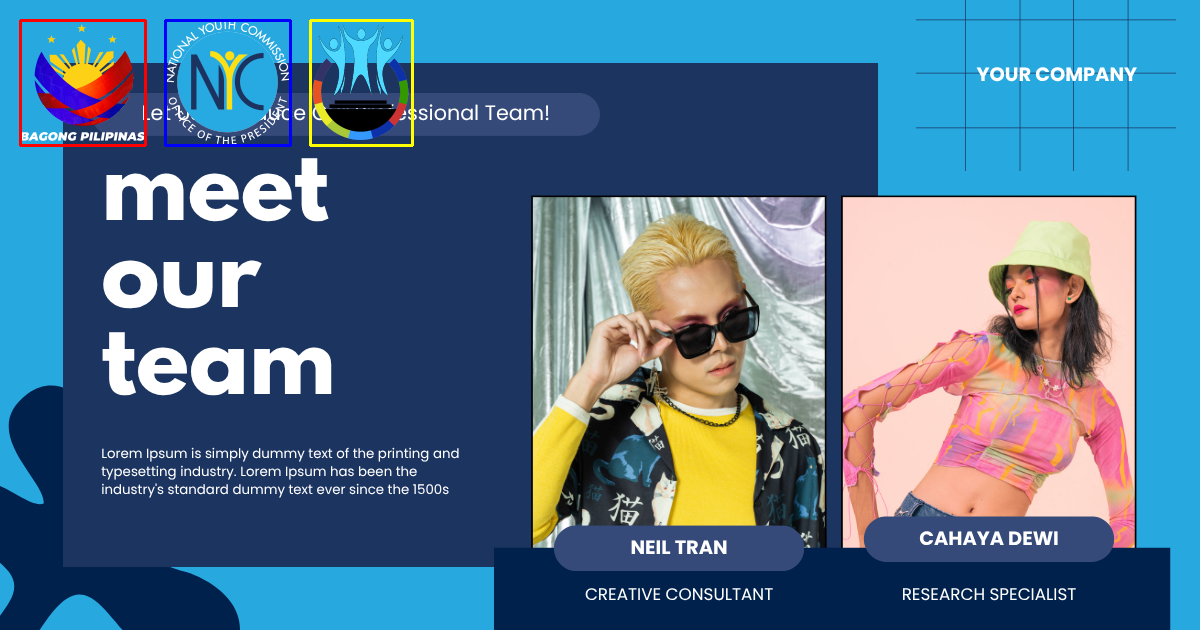

Placed [(2, [20, 20, 145, 145]), (0, [165, 20, 290, 145]), (6, [310, 20, 412, 145])] logos.


In [16]:
BBOX_COLORS = {
    "NYC":  (255,   0,   0),
    "BP":   (  0,   0, 255),
    "SK":   (  0, 255,   0),
    "YORP": (  0, 255, 255),
}

test_poster = cv2.imread(random.choice(poster_files_train))
candidates  = build_logo_candidates(loaded_logos, LOGO_CONFIG, CLASS_MAP)
n           = random.randint(3, min(4, len(candidates)))
selected    = random.sample(candidates, n)

display_img, placed_labels = place_logos_on_poster(test_poster, selected)

for (class_id, bbox), cand in zip(placed_labels, selected):
    x_min, y_min, x_max, y_max = bbox
    color = BBOX_COLORS.get(cand['type'], (255, 255, 255))
    cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), color, 2)

cv2_imshow(display_img)
print(f"Placed {(placed_labels)} logos.")

## Run Generation

In [17]:
print("Generating Training Data...")
num_generated_train = generate_dataset(
    poster_files        = poster_files_train,
    loaded_logos        = loaded_logos,
    logo_config         = LOGO_CONFIG,
    class_map           = CLASS_MAP,
    output_image_folder = OUTPUT_IMAGE_TRAIN_FOLDER,
    output_label_folder = OUTPUT_LABEL_TRAIN_FOLDER,
    start_file_num      = 200,
)

print("\nGenerating Test Data...")
num_generated_test = generate_dataset(
    poster_files        = poster_files_test,
    loaded_logos        = loaded_logos,
    logo_config         = LOGO_CONFIG,
    class_map           = CLASS_MAP,
    output_image_folder = OUTPUT_IMAGE_TEST_FOLDER,
    output_label_folder = OUTPUT_LABEL_TEST_FOLDER,
    start_file_num      = num_generated_train,
)

print("\nGenerating Validation Data...")
num_generated_val = generate_dataset(
    poster_files        = poster_files_val,
    loaded_logos        = loaded_logos,
    logo_config         = LOGO_CONFIG,
    class_map           = CLASS_MAP,
    output_image_folder = OUTPUT_IMAGE_VAL_FOLDER,
    output_label_folder = OUTPUT_LABEL_VAL_FOLDER,
    start_file_num      = num_generated_train + num_generated_test,
)

print(f"\nTotal images generated: {num_generated_train + num_generated_test + num_generated_val}")

Generating Training Data...
Skipped logos for 11.jpg (generation 1/3, output: image_200.jpg). Created empty label file.
Generated 4 logos for 11.jpg (generation 2/3, output: image_201.jpg).
Generated 4 logos for 11.jpg (generation 3/3, output: image_202.jpg).
Generated 3 logos for 37.jpg (generation 1/3, output: image_203.jpg).
Generated 4 logos for 37.jpg (generation 2/3, output: image_204.jpg).
Generated 4 logos for 37.jpg (generation 3/3, output: image_205.jpg).
Generated 4 logos for 38.jpg (generation 1/3, output: image_206.jpg).
Generated 4 logos for 38.jpg (generation 2/3, output: image_207.jpg).
Skipped logos for 38.jpg (generation 3/3, output: image_208.jpg). Created empty label file.
Generated 3 logos for 33.png (generation 1/3, output: image_209.jpg).
Generated 3 logos for 33.png (generation 2/3, output: image_210.jpg).
Generated 3 logos for 33.png (generation 3/3, output: image_211.jpg).
Generated 4 logos for 19.jpg (generation 1/3, output: image_212.jpg).
Generated 3 logos 

In [18]:
print("Train: ", num_generated_train)
print("Test:  ", num_generated_test)
print("Val:   ", num_generated_val)

Train:  1344
Test:   288
Val:    300
